In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd
import os
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from linearmodels import PanelOLS
import statsmodels.api as sm
import plotly.express as px
import seaborn as sns

In [2]:
zillow = pd.read_csv('../Data/zillow county.csv')
zillow_2017_cols = [col for col in zillow.columns if '2017' in str(col)]
zillow_2019_cols = [col for col in zillow.columns if '2019' in str(col)]

# Step 2: Calculate the average of 2017 and 2019 columns for each row
zillow['zillow_2017'] = zillow[zillow_2017_cols].mean(axis=1)
zillow['zillow_2019'] = zillow[zillow_2019_cols].mean(axis=1)

date_columns = [col for col in zillow.columns if '-' in str(col)]

# Step 2: Drop those date columns
zillow_filtered = zillow.drop(columns=date_columns)

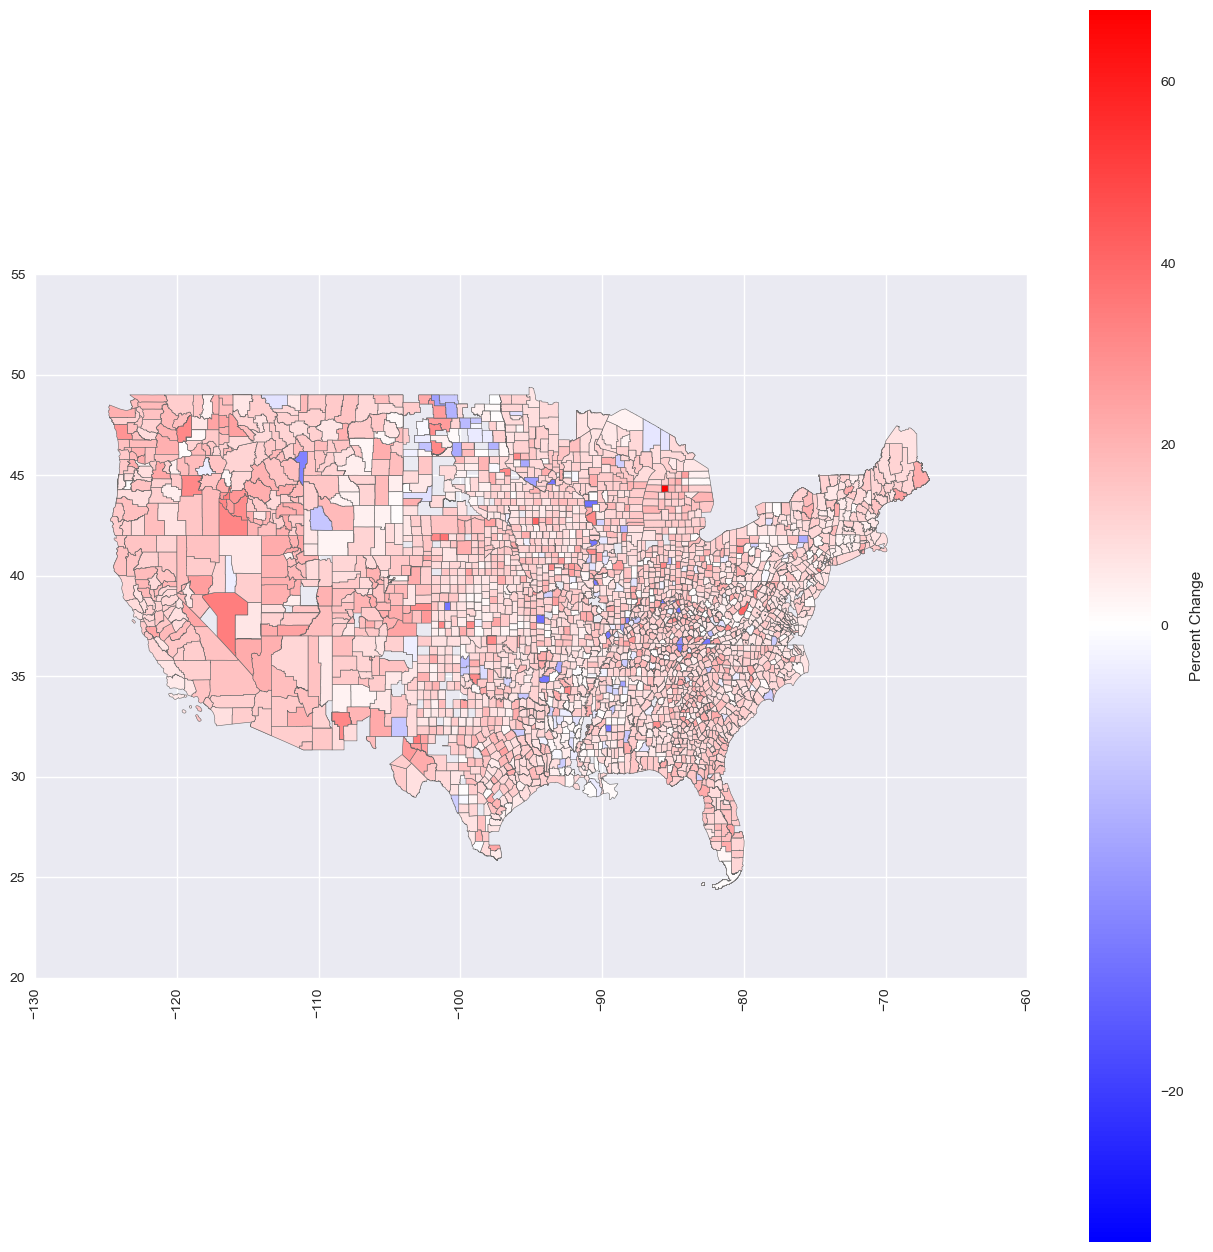

In [91]:
# Read the county shapefile
county = gpd.read_file(os.getcwd()+ '/tl_2019_us_county')
map_zillow = county.merge(zillow_filtered, left_on='NAMELSAD', right_on='RegionName')

# Calculate percent change
map_zillow['change'] = (map_zillow['zillow_2019'] - map_zillow['zillow_2017'])/map_zillow['zillow_2017'] * 100

# Set up the figure and axis
fig, ax = plt.subplots(1, figsize=(16, 16))
plt.xticks(rotation=90)

# Define normalization with the midpoint at 0
norm = TwoSlopeNorm(vmin=map_zillow["change"].min(), vcenter=0, vmax=map_zillow["change"].max())

# Plot the data using the 'bwr' colormap
map_zillow.plot(column="change", 
                cmap="bwr", 
                linewidth=0.4, 
                ax=ax, 
                edgecolor=".4", 
                legend=False, 
                norm=norm)

# Set x and y limits to focus on mainland US
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
sm._A = []  # Empty array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Percent Change')

# Create output path in Images folder
output_path = os.path.join('Images', 'Heat_Map_Zillow_PPI.png')

# Save the plot with high resolution
plt.savefig(output_path, 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1)

plt.show()
plt.close()

In [101]:
map_zillow_negative = map_zillow[map_zillow['change'] <0]


In [5]:
# Drop the last two columns
zillow = zillow.iloc[:, :-2]

# Select the columns to convert
column_names_to_convert = zillow.columns[9:]

# Convert the selected columns to datetime
new_column_names = pd.to_datetime(column_names_to_convert)

# Update the column names
zillow.columns = list(zillow.columns[:9]) + list(new_column_names)

# Drop columns outside the desired year range (2016-2020)
for column in new_column_names:
    column_year = column.year
    if not (2017 <= column_year <= 2019):
        zillow = zillow.drop(columns=[column])


In [6]:
countygdp = pd.read_csv('../Data/county gpd 2001-2023.csv', encoding='latin-1')

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_60515/1297155333.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  countygdp = pd.read_csv('../Data/county gpd 2001-2023.csv', encoding='latin-1')


In [7]:
countygdp = countygdp.dropna()

In [8]:
#clean data and rearrange by highest to lowest by gdp by county
exclude_terms = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 
    'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 
    'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 
    'Wisconsin', 'Wyoming','United States','Southeast' ,'Far West', 'Mideast', 'Great Lakes' ,'Southwest' ,'Plains',
 'New England','Rocky Mountain'
]

countygdp = countygdp[
    ~countygdp['GeoName'].str.contains('|'.join(exclude_terms), na=False) &
    pd.to_numeric(countygdp['2017'], errors='coerce').notnull()
]
countygdp['2017'] = pd.to_numeric(countygdp['2017'])
countygdp = countygdp.sort_values(by = '2017',ascending=False)
countygdp = countygdp[countygdp['Description'] == 'All industry total ']
countygdp = countygdp.reset_index()
countygdp = countygdp.drop(columns = ['index'])

In [9]:
#extract top 10 counties by gdp
top_gdp_countys = countygdp['GeoName'][:10]
top_gdp_countys = [i.strip() for i in countygdp['GeoName'][:10]]
top_gdp_countys = countygdp['GeoName'][:10].str.split(',').str[0] + " County"


In [10]:
#group data by county and then rearrange for plotting
top_county_housing = zillow[zillow['RegionName'].isin(top_gdp_countys)]
top_county_housing = top_county_housing.drop(columns = ['RegionID','SizeRank','StateCodeFIPS','MunicipalCodeFIPS'])
top_county_housing = top_county_housing.groupby('RegionName').mean(numeric_only = True)
top_county_housing_rotate = top_county_housing.T


In [11]:
#read in tariff data
tariffs = pd.read_csv('../Data/ustariffs-by-county.csv')

In [12]:
#remove columns except graphing data
tariffs_clean = tariffs.drop(columns = ['Unnamed: 0','emplvl_2017', 'fips', 'total_employment', 'int_area_fips',
       '2017_income', '2017_population', 'total_imp_pc', 'china_imp_pc'])
#filter for years wanted
tariffs_clean['time'] = pd.to_datetime(tariffs_clean['time'])
tariffs_clean = tariffs_clean[(tariffs_clean['time'].dt.year >= 2017) & (tariffs_clean['time'].dt.year <= 2019)]
tariffs_clean['state'] = tariffs_clean['area_fips'] // 1000
tariffs_grouped = tariffs_clean.drop(columns = ['area_fips'])
tariffs_grouped = tariffs_grouped.groupby(['state','time']).mean()

In [13]:
# State FIPS to Name Mapping
fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
    12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
    18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
    23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
    27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
    39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island',
    45: 'South Carolina', 46: 'South Dakota', 47: 'Tennessee', 48: 'Texas',
    49: 'Utah', 50: 'Vermont', 51: 'Virginia', 53: 'Washington', 54: 'West Virginia',
    55: 'Wisconsin', 56: 'Wyoming', 60: 'American Samoa', 66: 'Guam',
    69: 'Northern Mariana Islands', 72: 'Puerto Rico', 78: 'U.S. Virgin Islands'
}
#group by state
tariffs_grouped = tariffs_grouped.reset_index()
tariffs_grouped['state'] = tariffs_grouped['state'].map(fips_to_state)


In [14]:
#rotate df for each row have state and each column is date with tariff values
tariffs_pivoted = tariffs_grouped.pivot(index='time', columns='state', values='tariff')

In [15]:
tariffs_for_merge = tariffs_pivoted.drop(tariffs_pivoted.columns[1],axis = 1)

In [16]:
#drop first row so dates are close together since one uses start of month and other uses end
tariffs_pivoted = tariffs_pivoted.drop(index = '2017-01-01 00:00:00')
tariffs_pivoted = tariffs_pivoted.drop(columns = ['District of Columbia','Puerto Rico'])

In [17]:
#create result column to determine which states experienced biggest tariff changes
tariff_changes = tariffs_pivoted.iloc[-1] - tariffs_pivoted.iloc[0]
tariff_changes = tariff_changes.sort_values(ascending = False)

In [18]:
top_25_tariffs = tariff_changes[0:25]
bottom_25_tariffs = tariff_changes[25:len(tariff_changes)]

In [19]:
tariffs_pivoted['Top 25'] = tariffs_pivoted[top_25_tariffs.index[0]]

for state in top_25_tariffs.index[1:]:  
    tariffs_pivoted['Top 25'] = tariffs_pivoted[['Top 25', state]].mean(axis=1)

tariffs_pivoted['Bottom 25'] = tariffs_pivoted[bottom_25_tariffs.index[0]]

for state in bottom_25_tariffs.index[1:]:
    tariffs_pivoted['Bottom 25'] = tariffs_pivoted[['Bottom 25', state]].mean(axis=1)


In [20]:
def analyze_tariff_quartiles(tariff_series):
    # Calculate quartile indices
    n = len(tariff_series)
    q1_idx = n // 4
    q2_idx = n // 2
    q3_idx = (3 * n) // 4
    
    # Split into quartiles (assuming series is already sorted from highest to lowest)
    q1 = tariff_series[:q1_idx]  # Top 25%
    q2 = tariff_series[q1_idx:q2_idx]  # 50-75%
    q3 = tariff_series[q2_idx:q3_idx]  # 25-50%
    q4 = tariff_series[q3_idx:] 

    return q1,q2,q3,q4

quartiles = analyze_tariff_quartiles(tariff_changes)

In [21]:
quartile_count = 0
for quartile in quartiles:
    quartile_count +=1
    tariffs_pivoted[f'q{quartile_count}'] = tariffs_pivoted[quartile.index[0]]
    for state in quartile.index[1:]:
        tariffs_pivoted[f'q{quartile_count}'] = tariffs_pivoted[[f'q{quartile_count}',state]].mean(axis = 1)


In [22]:
tariffs_pivoted = tariffs_pivoted.drop(columns = ['Top 25','Bottom 25','q1','q2','q3','q4'])

In [23]:
tariffs_clean['area_fips'] = tariffs_clean['area_fips'].astype(str).str.zfill(5)

In [24]:
#make county FIPS column
zillow['CountyFIPS'] = (
    zillow['StateCodeFIPS'].astype(str).str.zfill(2) + 
    zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
)

#clean
zillow_county = zillow.drop(columns = ['SizeRank','StateName','State','Metro','StateCodeFIPS','MunicipalCodeFIPS','RegionName','RegionID','RegionType'])

In [25]:
# Filter out special FIPS codes
tariffs_clean = tariffs_clean[~tariffs_clean['area_fips'].astype(str).str.endswith('999')]

# Standardize to 5 digits
tariffs_clean['area_fips'] = tariffs_clean['area_fips'].astype(str).str.zfill(5)


In [26]:
tariffs_clean = tariffs_clean[tariffs_clean['time'] != '2017-01-01 00:00:00']
tariffs_clean = tariffs_clean.reset_index(drop = True)

In [27]:
# Melt the dataframe
zillow_county_long = pd.melt( 
    zillow_county,
    id_vars=['CountyFIPS'],
    value_vars=[col for col in zillow_county.columns if isinstance(col, pd.Timestamp)],  # Check for Timestamp columns
    var_name='time',
    value_name='value'
)

# Convert time to string format YYYY-MM-DD
zillow_county_long['time'] = zillow_county_long['time'].dt.strftime('%Y-%m-%d')

# Sort the data
zillow_county_long = zillow_county_long.sort_values(['CountyFIPS', 'time'])


In [28]:
zillow_county_long = zillow_county_long.reset_index()

# Convert time to datetime
zillow_county_long['time'] = pd.to_datetime(zillow_county_long['time'])

# Add 1 day to move to start of next month
zillow_county_long['time'] = zillow_county_long['time'] + pd.DateOffset(days=1)

# Convert back to string format YYYY-MM-DD
zillow_county_long['time'] = zillow_county_long['time'].dt.strftime('%Y-%m-%d')

zillow_county_long = zillow_county_long.drop(columns = ['index'])
zillow_county_long = zillow_county_long[zillow_county_long['time'] != '2020-01-01 00:00:00']
zillow_county_long['time'] = pd.to_datetime(zillow_county_long['time'])

In [29]:
ht_county = zillow_county_long.merge(tariffs_clean, left_on = ['time','CountyFIPS'],right_on = ['time','area_fips'])

# Convert time columns to datetime in both DataFrames
ht_county['time'] = pd.to_datetime(ht_county['time'])
tariffs['time'] = pd.to_datetime(tariffs['time'])

# Make sure area_fips has the same type in both DataFrames
# If it should be integer:
ht_county['area_fips'] = ht_county['area_fips'].astype(int)
tariffs['area_fips'] = tariffs['area_fips'].astype(int)

# Now try the merge
ht_county = ht_county.merge(tariffs, left_on=['time', 'area_fips'], right_on=['time', 'area_fips'])

ht_county = ht_county.drop(columns = ['area_fips','state','Unnamed: 0', 'fips', 'total_employment', 'int_area_fips',
       '2017_income', 'total_imp_pc', 'china_imp_pc','tariff_x'],axis = 1)
ht_county = ht_county.rename(columns = {'value': 'hprices','tariff_y':'tariff'})

# First reshape the GDP data from wide to long format
gdp_long = pd.melt(
    countygdp,
    id_vars=['GeoFIPS', 'GeoName'],  
    value_vars=[str(year) for year in range(2001, 2024)],  
    var_name='year',
    value_name='gdp'
)

# Clean up the FIPS codes
gdp_long['GeoFIPS'] = gdp_long['GeoFIPS'].str.replace('"', '').str.zfill(5)

# Rename to match other df
gdp_long = gdp_long.rename(columns={'GeoFIPS': 'CountyFIPS'})

# Convert year to int64 in gdp_long
gdp_long['year'] = gdp_long['year'].astype(int)

# Add year column to ht_county
ht_county['year'] = ht_county['time'].dt.year

gdp_long['CountyFIPS'] = gdp_long['CountyFIPS'].str.strip()
#merge
merged_df = ht_county.merge(
    gdp_long[['CountyFIPS', 'year', 'gdp']], 
    on=['CountyFIPS', 'year']
)

# Drop the temporary year column 
ht_county = merged_df.drop('year', axis=1)

In [32]:
zillow_second_read = pd.read_csv('../Data/zillow county.csv')
# Select the columns to convert
column_names_to_convert = zillow_second_read.columns[9:]

# Convert the selected columns to datetime
new_column_names = pd.to_datetime(column_names_to_convert)

# Update the column names
zillow_second_read.columns = list(zillow_second_read.columns[:9]) + list(new_column_names)

# Drop columns outside the desired year range (2016-2020)
for column in new_column_names:
    column_year = column.year
    if not (2016 <= column_year <= 2019):
        zillow_second_read = zillow_second_read.drop(columns=[column])

# Make county FIPS column
zillow_second_read['CountyFIPS'] = (
    zillow_second_read['StateCodeFIPS'].astype(str).str.zfill(2) + 
    zillow_second_read['MunicipalCodeFIPS'].astype(str).str.zfill(3)
)

# Clean
zillow_county_second_read = zillow_second_read.drop(columns=['SizeRank', 'StateName', 'State', 'Metro', 
                                                 'StateCodeFIPS', 'MunicipalCodeFIPS', 
                                                 'RegionName', 'RegionID', 'RegionType'])

# Melt the dataframe
zillow_county_second_long = pd.melt(
    zillow_county_second_read,
    id_vars=['CountyFIPS'],
    value_vars=[col for col in zillow_county_second_read.columns if isinstance(col, pd.Timestamp)],  # Check for Timestamp columns
    var_name='time',
    value_name='value'
)

# Convert time to string format YYYY-MM-DD
zillow_county_second_long['time'] = zillow_county_second_long['time'].dt.strftime('%Y-%m-%d')

# Sort the data
zillow_county_second_long = zillow_county_second_long.sort_values(['CountyFIPS', 'time'])

zillow_county_second_long = zillow_county_second_long.reset_index()

# Convert time to datetime
zillow_county_second_long['time'] = pd.to_datetime(zillow_county_second_long['time'])

# Add 1 day to move to start of next month
zillow_county_second_long['time'] = zillow_county_second_long['time'] + pd.DateOffset(days=1)

# Convert back to string format YYYY-MM-DD
zillow_county_second_long['time'] = zillow_county_second_long['time'].dt.strftime('%Y-%m-%d')

zillow_county_second_long = zillow_county_second_long.drop(columns=['index'])
zillow_county_second_long = zillow_county_second_long[zillow_county_second_long['time'] != '2020-01-01 00:00:00']
zillow_county_second_long['time'] = pd.to_datetime(zillow_county_second_long['time'])

# Convert time columns to datetime in both DataFrames
zillow_county_second_long['time'] = pd.to_datetime(zillow_county_second_long['time'])
tariffs['time'] = pd.to_datetime(tariffs['time'])


zillow_county_second_long['area_fips'] = zillow_county_second_long['CountyFIPS'].astype(int)
tariffs['area_fips'] = tariffs['area_fips'].astype(int)

ht_county2 = zillow_county_second_long.merge(tariffs, left_on=['time', 'area_fips'], right_on=['time', 'area_fips'])

ht_county2 = ht_county2.drop(columns=['area_fips', 'Unnamed: 0', 'fips', 'total_employment', 'int_area_fips',
                                      '2017_income', 'total_imp_pc', 'china_imp_pc'], axis=1)
ht_county2 = ht_county2.rename(columns={'value': 'hprices'})

# First reshape the GDP data from wide to long format
gdp_long = pd.melt(
    countygdp,
    id_vars=['GeoFIPS', 'GeoName'],  
    value_vars=[str(year) for year in range(2001, 2024)],  
    var_name='year',
    value_name='gdp'
)

# Clean up the FIPS codes
gdp_long['GeoFIPS'] = gdp_long['GeoFIPS'].str.replace('"', '').str.zfill(5)

# Rename to match other df
gdp_long = gdp_long.rename(columns={'GeoFIPS': 'CountyFIPS'})

# Convert year to int64 in gdp_long
gdp_long['year'] = gdp_long['year'].astype(int)

# Add year column to ht_county2
ht_county2['year'] = ht_county2['time'].dt.year

gdp_long['CountyFIPS'] = gdp_long['CountyFIPS'].str.strip()

# Merge
merged_df = ht_county2.merge(
    gdp_long[['CountyFIPS', 'year', 'gdp']], 
    on=['CountyFIPS', 'year']
)

# Drop the temporary year column 
ht_county2 = merged_df.drop('year', axis=1)


In [34]:
tariffs_clean = tariffs_clean.drop('state',axis = 1)
tariffs_clean_pivoted = tariffs_clean.pivot(index='area_fips', columns='time', values='tariff')
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index()

In [35]:
tariffs_clean_pivoted['change'] = tariffs_clean_pivoted.iloc[:,-1] - tariffs_clean_pivoted.iloc[:,1]

In [37]:
tariffs_clean_pivoted = tariffs_clean_pivoted.sort_values(by = ['change'],ascending = False)
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index(drop = True)
tariffs_clean_pivoted = tariffs_clean_pivoted.dropna()

In [38]:
# Create a new column 'quartile' based on the 'change' column
tariffs_clean_pivoted['quartile'] = pd.qcut(tariffs_clean_pivoted['change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# If you want to see how many rows are in each quartile:
print(tariffs_clean_pivoted['quartile'].value_counts().sort_index())

# If you want to see the range of values in each quartile:
print(tariffs_clean_pivoted.groupby('quartile')['change'].agg(['min', 'max']))

# If you need to split into separate dataframes:
q1 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q1']
q2 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q2']
q3 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q3']
q4 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q4']

Q1    796
Q2    796
Q3    796
Q4    796
Name: quartile, dtype: int64
               min        max
quartile                     
Q1        0.000000   0.924980
Q2        0.924998   2.123877
Q3        2.124994   4.051837
Q4        4.052744  23.980999


In [51]:
zillow_q1_tariffs = zillow[zillow['CountyFIPS'].isin(q1['area_fips'])]
zillow_q4_tariffs = zillow[zillow['CountyFIPS'].isin(q4['area_fips'])]

drop_columns = ['Metro','StateCodeFIPS','MunicipalCodeFIPS','State','StateName','RegionType','RegionName','SizeRank','RegionID','CountyFIPS']
zillow_q1_tariffs = zillow_q1_tariffs.drop(columns = drop_columns)
zillow_q4_tariffs = zillow_q4_tariffs.drop(columns = drop_columns)
zillow_q1_tariffs_mean = pd.DataFrame([np.log(zillow_q1_tariffs.mean())])
zillow_q4_tariffs_mean = pd.DataFrame([np.log(zillow_q4_tariffs.mean())])
zq14_diff = zillow_q4_tariffs_mean - zillow_q1_tariffs_mean

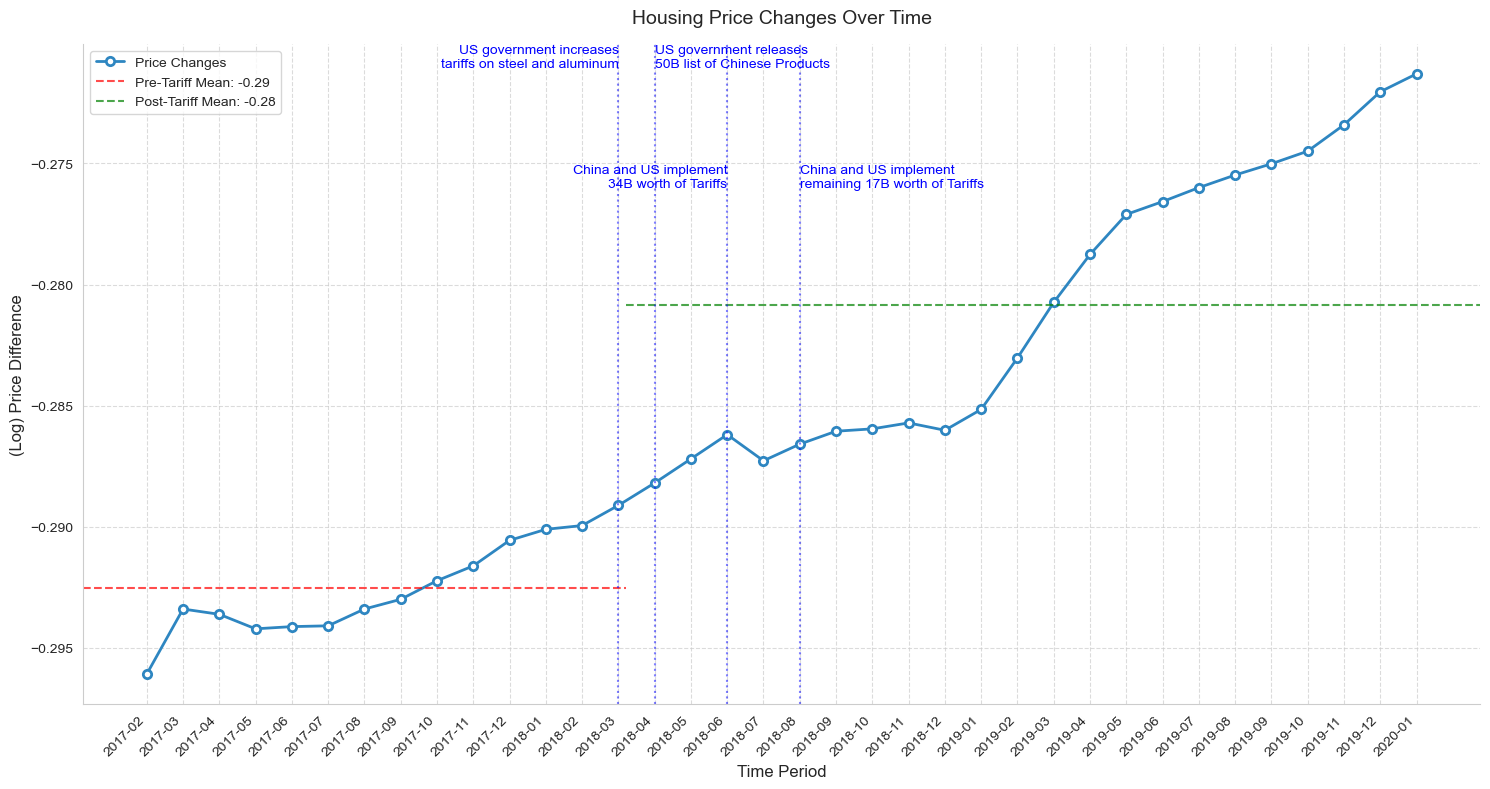

In [53]:
# Calculate averages before and after the split date
split_date = pd.Timestamp('2018-02-28')
before_mask = zq14_diff.columns <= split_date
after_mask = zq14_diff.columns > split_date
before_mean = zq14_diff.iloc[0, before_mask].mean()
after_mean = zq14_diff.iloc[0, after_mask].mean()

# Create the plot
plt.figure(figsize=(15, 8))

# Convert dates to month format and shift them forward by one month for x-axis
x_dates = [(d + pd.DateOffset(months=1)).strftime('%Y-%m') for d in zq14_diff.columns]

# Main line plot
plt.plot(x_dates, zq14_diff.iloc[0], 
         marker='o', 
         linewidth=2, 
         markersize=6,
         color='#2E86C1',
         linestyle='-',
         markerfacecolor='white',
         markeredgewidth=2)

# Add horizontal mean lines
plt.axhline(y=before_mean, color='r', linestyle='--', alpha=0.7, 
           xmin=0, xmax=len(before_mask[before_mask])/len(zq14_diff.columns))
plt.axhline(y=after_mean, color='g', linestyle='--', alpha=0.7,
           xmin=len(before_mask[before_mask])/len(zq14_diff.columns), xmax=1)

# Shift the vertical line dates forward by one month as well
shifted_split_date = (split_date + pd.DateOffset(months=1)).strftime('%Y-%m')
plt.axvline(x=shifted_split_date, color='blue', linestyle=':', alpha=0.5)
plt.text(shifted_split_date, plt.ylim()[1], 
         'US government increases\ntariffs on steel and aluminum',
         verticalalignment='top',
         horizontalalignment='right',
         color='blue',
         fontsize=10)

# Add line for us releasing list (shifted)
list_date = pd.Timestamp('2018-03-31')
shifted_list_date = (list_date + pd.DateOffset(months=1)).strftime('%Y-%m')
plt.axvline(x=shifted_list_date, color='blue', linestyle=':', alpha=0.5)
plt.text(shifted_list_date, plt.ylim()[1], 
         'US government releases\n50B list of Chinese Products',
         verticalalignment='top',
         horizontalalignment='left',
         color='blue',
         fontsize=10)

# Add line for implementation date
tariff_date = pd.Timestamp('2018-05-31')
shifted_list_date = (tariff_date + pd.DateOffset(months=1)).strftime('%Y-%m')
plt.axvline(x=shifted_list_date, color='blue', linestyle=':', alpha=0.5)
plt.text(shifted_list_date, -.275, 
         'China and US implement\n34B worth of Tariffs',
         verticalalignment='top',
         horizontalalignment='right',
         color='blue',
         fontsize=10)

tariff_date = pd.Timestamp('2018-07-31')
shifted_list_date = (tariff_date + pd.DateOffset(months=1)).strftime('%Y-%m')
plt.axvline(x=shifted_list_date, color='blue', linestyle=':', alpha=0.5)
plt.text(shifted_list_date, -.275, 
         'China and US implement\nremaining 17B worth of Tariffs',
         verticalalignment='top',
         horizontalalignment='left',
         color='blue',
         fontsize=10)


# Improve grid
plt.grid(True, linestyle='--', alpha=0.7)
# Enhance labels and title
plt.title('Housing Price Changes Over Time', fontsize=14, pad=15)
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('(Log) Price Difference', fontsize=12)
# Format x-axis
plt.xticks(rotation=45, ha='right')
# Add legend
plt.legend(['Price Changes', 
           f'Pre-Tariff Mean: {before_mean:.2f}', 
           f'Post-Tariff Mean: {after_mean:.2f}'],
           loc='best')
# Clean up layout
plt.tight_layout()
# Remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Clean up layout
plt.tight_layout()

# Remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Save the figure
plt.savefig('../images/housing_price_changes.png', 
            dpi=300,              # Higher resolution
            bbox_inches='tight',  # Ensures no labels are cut off
            facecolor='white',    # White background
            format='png')         # File format

# Show the plot
plt.show()


In [54]:
tariffs_clean_pivoted['tariff_change'] = tariffs_clean_pivoted.iloc[:,-3] - tariffs_clean_pivoted.iloc[:,2]

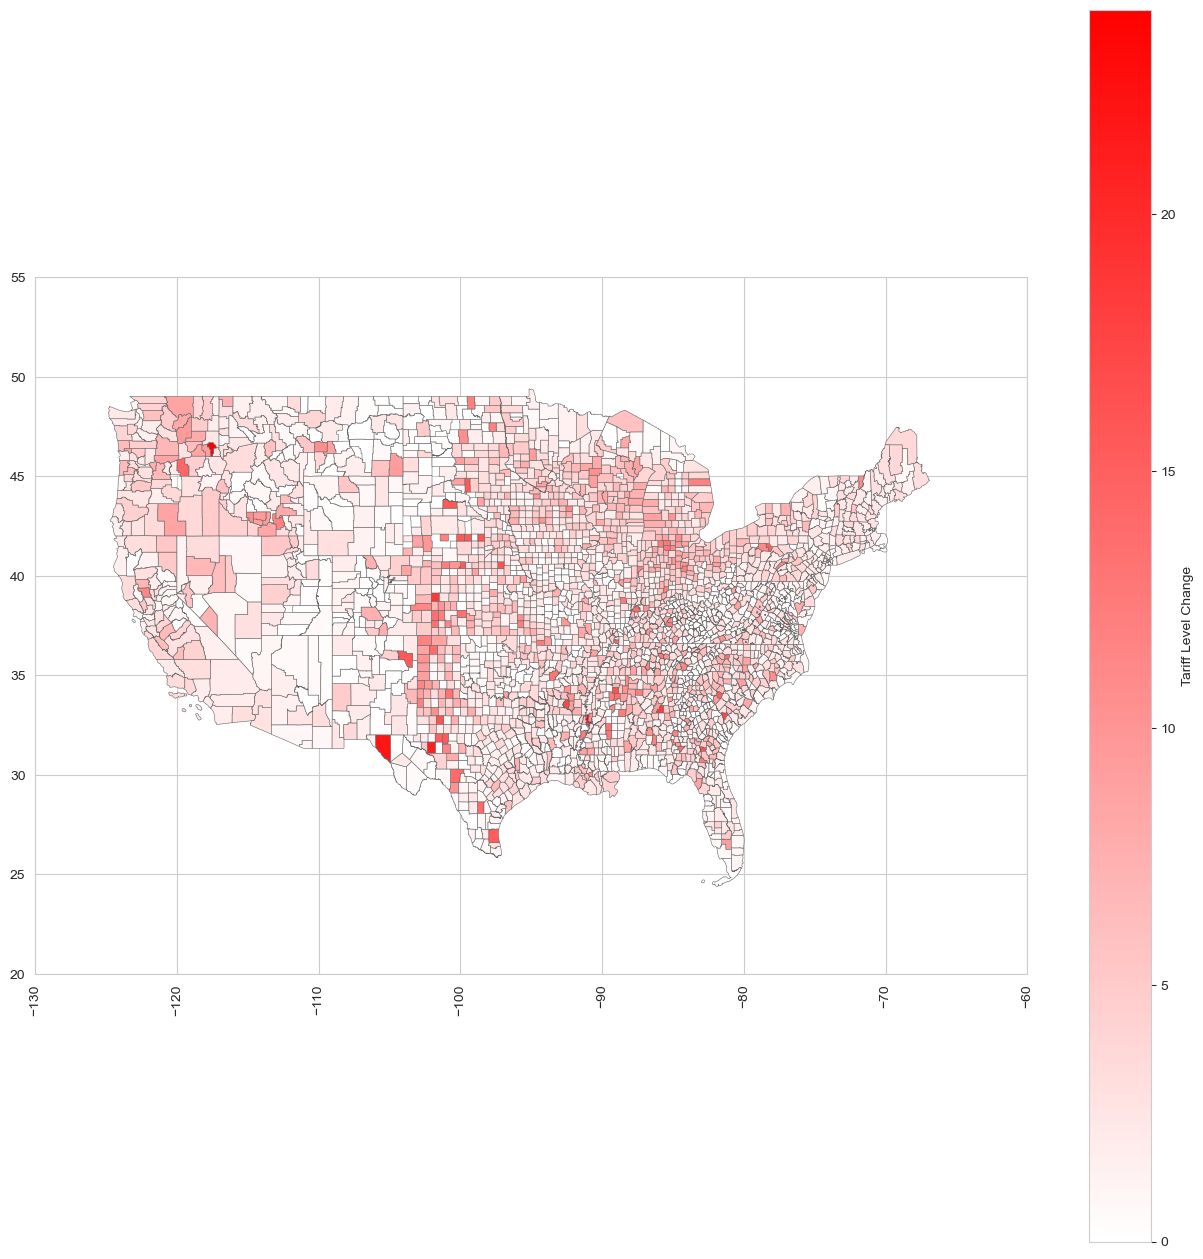

In [55]:
# Read the county shapefile
county = gpd.read_file(os.getcwd()+ '/tl_2019_us_county')
map_tariffs = county.merge(tariffs_clean_pivoted, left_on='GEOID', right_on='area_fips')

# Set up the figure and axis
fig, ax = plt.subplots(1, figsize=(16, 16))
plt.xticks(rotation=90)

# Create a custom white to red colormap
from matplotlib.colors import LinearSegmentedColormap
white_red = LinearSegmentedColormap.from_list('white_red', ['white', 'red'])

# Use a standard normalization
norm = plt.Normalize(vmin=map_tariffs["tariff_change"].min(), vmax=map_tariffs["tariff_change"].max())

# Plot the data using the custom white-to-red colormap
map_tariffs.plot(column="tariff_change", 
                cmap=white_red, 
                linewidth=0.4, 
                ax=ax, 
                edgecolor=".4", 
                legend=False, 
                norm=norm)

# Set x and y limits to focus on mainland US
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap=white_red, norm=norm)
sm._A = []  # Empty array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Tariff Level Change')

# Create output path in Images folder
output_path = os.path.join('Images', 'Heat_Map_tariff.png')

# Save the plot with high resolution
plt.savefig(output_path, 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1)

plt.savefig('../images/tariff_change_heatmap.png', 
            dpi=300,              # Higher resolution
            bbox_inches='tight',  # Ensures no labels are cut off
            facecolor='white',    # White background
            format='png')         # File format

plt.show()

In [56]:
# Calculate the difference between the second-to-last column and first column
zillow_county['hp_change'] = zillow_county.iloc[:,-2] - zillow_county.iloc[:,0]
zillow_county = zillow_county.dropna()

In [57]:
tz_merge = tariffs_clean_pivoted.merge(zillow_county, left_on = 'area_fips',right_on = 'CountyFIPS')
tariffs['area_fips'] = tariffs['area_fips'].astype(str)
tz_merge = tz_merge.merge(tariffs,left_on = 'area_fips',right_on = 'area_fips')

In [58]:
tz_merge = tz_merge[['area_fips', 'tariff_change', 'hp_change','2017_population']]
tz_merge['hp_change'] = np.log(tz_merge['hp_change'])

/Users/griffinhsu/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
